<a href="https://colab.research.google.com/github/vitor-laudares/Trabalho-Final-Py_Stellantis/blob/main/trabalho_final_py_stellantis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Trabalho final da disciplina de programação em Python

Alunos:

Anna Beatriz

Joao Pedro

Matheus Rocha

Pedro Henrique

Vitor Laudares


---




## Tema: Emissão de CO2 por veículos

O dataset escolhido, apresenta mais de 7 mil carros de diferentes montadoras. As características presentes são:

Make

Model

Vehicle Class

Engine Size(L)

Cylinders

Transmission

Fuel Type

Fuel Consumption City (L/100 km)

Fuel Consumption Hwy (L/100 km)

Fuel Consumption Comb (L/100 km)

Fuel Consumption Comb (mpg)

CO2 Emissions(g/km)

In [ ]:
# Imports e carregamento do arquivo
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
data = pd.read_csv('co2.csv')

# No data.info, vemos que não existem buracos nem dados faltantes
#data.info()


In [ ]:
# Conversão de L/100km para km/L
colunas_consumo = ['Fuel Consumption City (L/100 km)',
                   'Fuel Consumption Hwy (L/100 km)',
                   'Fuel Consumption Comb (L/100 km)']
for coluna in colunas_consumo:
    data[coluna] = 100 / data[coluna]
    data.rename(columns={coluna: coluna.replace('L/100 km', 'km/L')}, inplace=True)
    #data.info()

stellantis_marcas = ['CHRYSLER', 'DODGE', 'FIAT', 'JEEP', 'RAM', 'ALFA ROMEO', 'MASERATI']
data.loc[data['Make'] == 'SRT', 'Make'] = 'DODGE'

lista_marcas = []

for marca in data['Make']:
    if marca not in lista_marcas_manual:
        lista_marcas.append(marca)

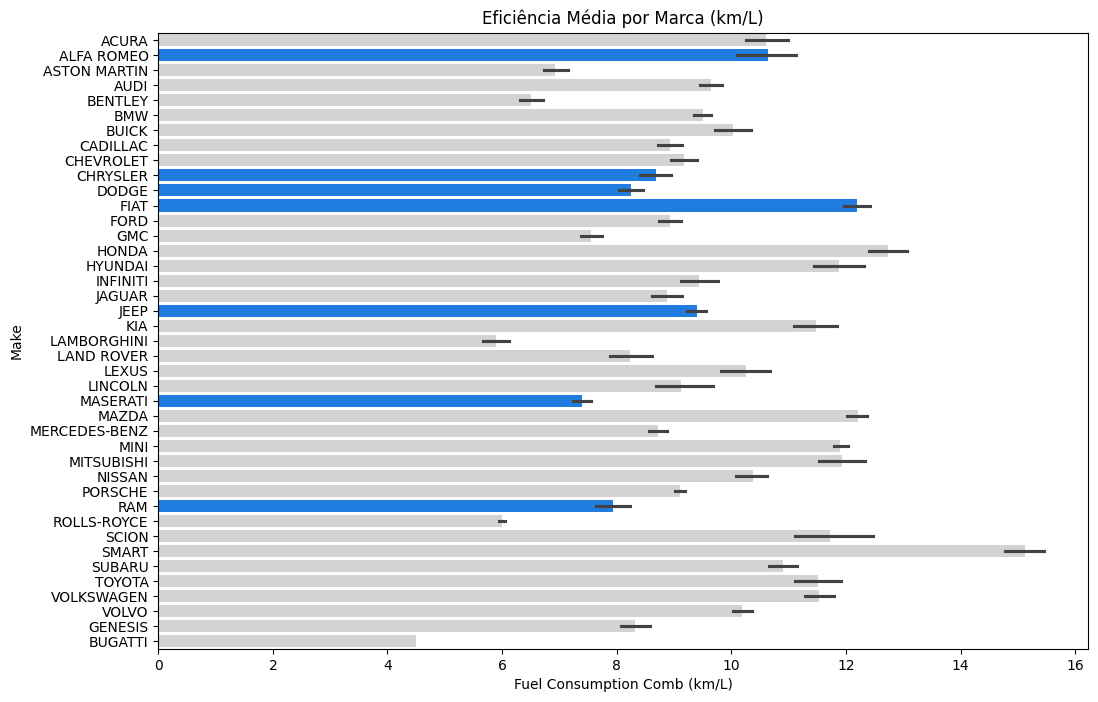

In [ ]:
cores = {}
# Percorre a lista de marcas
for marca in lista_marcas:
    # Aplica a verificação se a marca está no grupo stellantes
    if marca in stellantis_marcas:
        cores[marca] = '#007bff'  # Cor Stellantis
    else:
        cores[marca] = '#d3d3d3'  # Cor Cinza (outras marcas)
plt.figure(figsize=(12, 8))
sns.barplot(
    data=data,
    x='Fuel Consumption Comb (km/L)',
    y='Make',
    hue='Make',
    palette=cores,
    legend=False
)

plt.title('Eficiência Média por Marca (km/L)')
plt.show()
